## COMPARAISON ENTRE DBSCAN ET KMEANS

Aperçu du dataset :

== DBSCAN ==


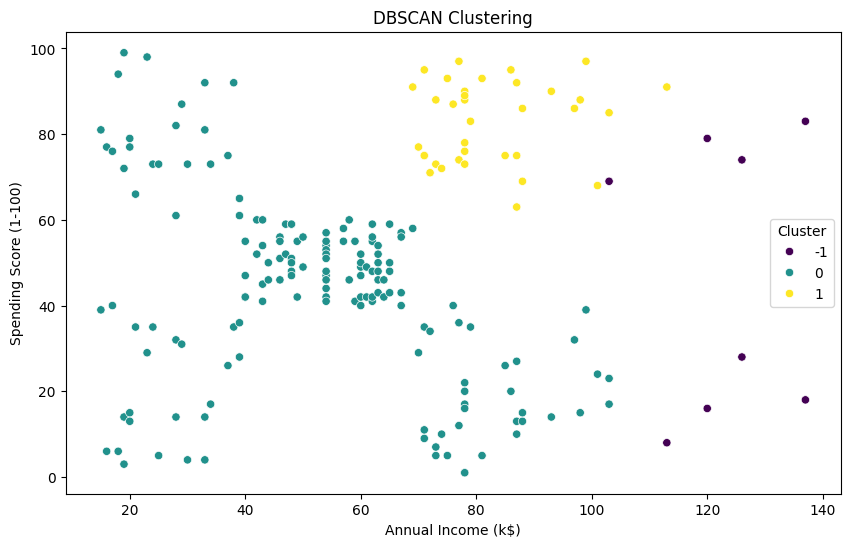

Score de silhouette pour DBSCAN : 0.35044619989666004

== K-means ==


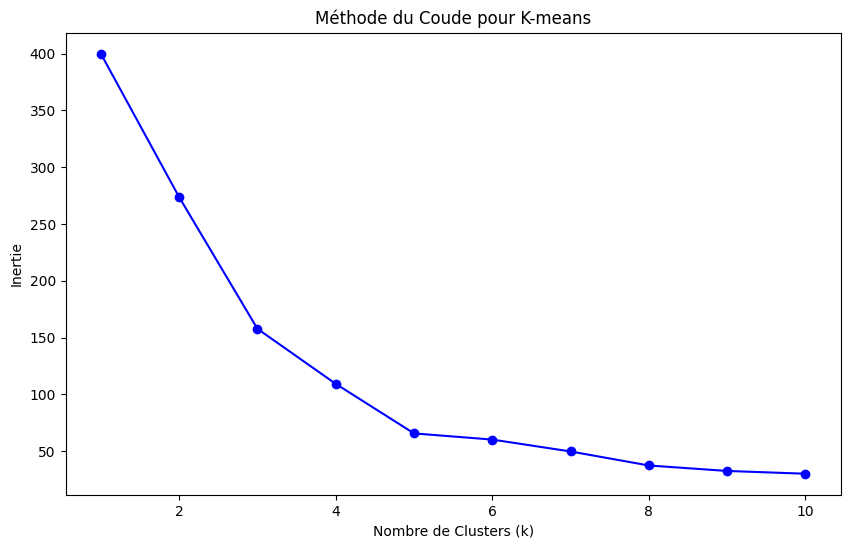

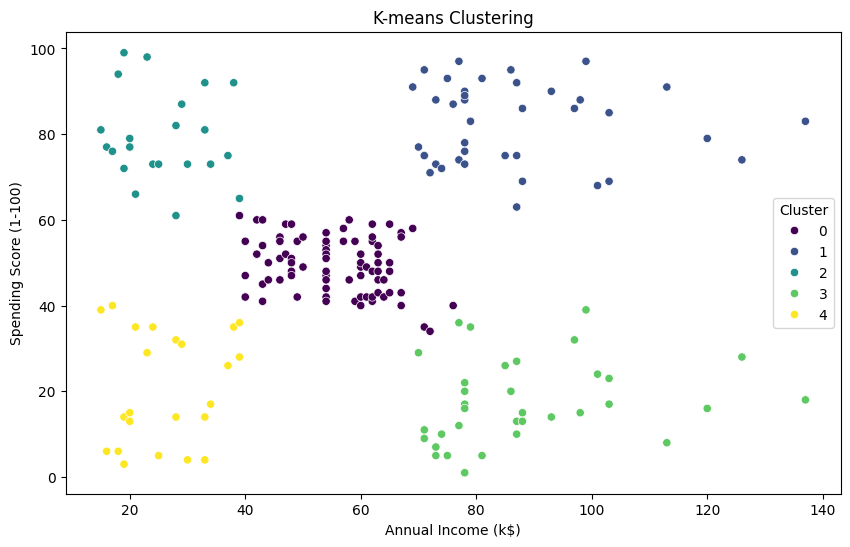

Score de silhouette pour K-means : 0.5546571631111091


In [1]:
# Importer les bibliothèques nécessaires
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN, KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# Charger le dataset
url = 'Mall_Customers.csv'
data = pd.read_csv(url)

# Afficher un aperçu du dataset
print("Aperçu du dataset :")
data.head()

# Garder seulement les colonnes pertinentes pour la segmentation (par exemple, 'Annual Income' et 'Spending Score')
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]

# Normaliser les données pour DBSCAN et K-means
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

### 1. Implémentation de DBSCAN
print("\n== DBSCAN ==")
# Initialisation de DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

# Ajouter les étiquettes DBSCAN au dataset
data['DBSCAN_Cluster'] = dbscan_labels

# Visualiser les clusters DBSCAN
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='DBSCAN_Cluster', data=data, palette='viridis')
plt.title('DBSCAN Clustering')
plt.legend(title='Cluster')
plt.show()

# Calculer le score silhouette pour DBSCAN
silhouette_dbscan = silhouette_score(X_scaled, dbscan_labels)
print(f"Score de silhouette pour DBSCAN : {silhouette_dbscan}")

### 2. Implémentation de K-means
print("\n== K-means ==")
# Déterminer le nombre optimal de clusters en utilisant la méthode du coude
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

# Visualisation de la méthode du coude
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-')
plt.xlabel('Nombre de Clusters (k)')
plt.ylabel("Inertie")
plt.title("Méthode du Coude pour K-means")
plt.show()

# Appliquer K-means avec un nombre de clusters choisi (par exemple, k=5)
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Ajouter les étiquettes K-means au dataset
data['KMeans_Cluster'] = kmeans_labels

# Visualiser les clusters K-means
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='KMeans_Cluster', data=data, palette='viridis')
plt.title('K-means Clustering')
plt.legend(title='Cluster')
plt.show()

# Calculer le score silhouette pour K-means
silhouette_kmeans = silhouette_score(X_scaled, kmeans_labels)
print(f"Score de silhouette pour K-means : {silhouette_kmeans}")
